# ADS-505 Group Project: Rossmann Store Sales
## Part 3: Modeling, Tuning, and Final Model Selection
### Author: Christopher Andra

This section builds and compares regression models to predict Rossmann daily sales using promotion, store, calendar, holiday, and competition characteristics.

The goal is to compare model performance, tune the stronger models, and select the final model that best supports the project's business objective.

In [1]:
#import packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import gc

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import BaggingRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


### Loading/checking modeling dataset from part 2

In [2]:

df = pd.read_csv("../data/processed/rossmann_model_dataset.csv", low_memory=False)
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (844392, 15)


,Store,DayOfWeek,Promo,Month,Day,Year,IsWeekend,Season,CompetitionDistance,CompetitionGroup,StoreType,Assortment,StateHoliday,SchoolHoliday,Sales
0,85,2,0,1,1,2013,False,Winter,1870.0,1-5km,b,a,a,1,4220
1,259,2,0,1,1,2013,False,Winter,210.0,<1km,b,b,a,1,6851
2,262,2,0,1,1,2013,False,Winter,1180.0,1-5km,b,a,a,1,17267
3,274,2,0,1,1,2013,False,Winter,3640.0,1-5km,b,b,a,1,3102
4,335,2,0,1,1,2013,False,Winter,90.0,<1km,b,a,a,1,2401


In [3]:
# Verify data types and missing values
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

Store                    int64
DayOfWeek                int64
Promo                    int64
Month                    int64
Day                      int64
Year                     int64
IsWeekend                 bool
Season                     str
CompetitionDistance    float64
CompetitionGroup           str
StoreType                  str
Assortment                 str
StateHoliday               str
SchoolHoliday            int64
Sales                    int64
dtype: object

Missing values:
Store                  0
DayOfWeek              0
Promo                  0
Month                  0
Day                    0
Year                   0
IsWeekend              0
Season                 0
CompetitionDistance    0
CompetitionGroup       0
StoreType              0
Assortment             0
StateHoliday           0
SchoolHoliday          0
Sales                  0
dtype: int64


In [4]:
# Separate predictors and target
X = df.drop(columns=["Sales"])
y = df["Sales"]

print("Predictor shape:", X.shape)
print("Target shape:", y.shape)

Predictor shape: (844392, 14)
Target shape: (844392,)


In [5]:
# Categorical and numeric variables
categorical_cols = [
    "Season",
    "CompetitionGroup",
    "StoreType",
    "Assortment",
    "StateHoliday"
]

numeric_cols = [
    "Store",
    "DayOfWeek",
    "Promo",
    "Month",
    "Day",
    "Year",
    "IsWeekend",
    "CompetitionDistance",
    "SchoolHoliday"
]

print("Categorical columns:", categorical_cols)
print("Numeric columns:", numeric_cols)

Categorical columns: ['Season', 'CompetitionGroup', 'StoreType', 'Assortment', 'StateHoliday']
Numeric columns: ['Store', 'DayOfWeek', 'Promo', 'Month', 'Day', 'Year', 'IsWeekend', 'CompetitionDistance', 'SchoolHoliday']


In [6]:
# One-hot encode categorical variables
preprocessor = ColumnTransformer(
    transformers=[("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols )],
    remainder="passthrough")

In [7]:
# Load train, validation, and test sets created in Part 2
train = pd.read_csv("../data/processed/train.csv", low_memory=False)
val = pd.read_csv("../data/processed/validation.csv", low_memory=False)
test = pd.read_csv("../data/processed/test.csv", low_memory=False)

print("Train:", train.shape)
print("Validation:", val.shape)
print("Test:", test.shape)

Train: (591074, 15)
Validation: (126658, 15)
Test: (126660, 15)


In [8]:
# Separate predictors and target
X_train = train.drop(columns=["Sales"])
y_train = train["Sales"]

X_val = val.drop(columns=["Sales"])
y_val = val["Sales"]

X_test = test.drop(columns=["Sales"])
y_test = test["Sales"]

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

X_train: (591074, 14)
y_train: (591074,)


In [9]:
# Remove duplicate DataFrames that are no longer needed
del df
del X
del y
del train
del val
del test

gc.collect()

0

### Baseline model

In [10]:
# Baseline model: predict the average training sales for every validation row
baseline_pred = np.full(len(y_val), y_train.mean())

baseline_mae = mean_absolute_error(y_val, baseline_pred)
baseline_rmse = np.sqrt(mean_squared_error(y_val, baseline_pred))
baseline_r2 = r2_score(y_val, baseline_pred)

print("Baseline Model")
print("MAE:", round(baseline_mae, 2))
print("RMSE:", round(baseline_rmse, 2))
print("R²:", round(baseline_r2, 4))

Baseline Model
MAE: 2320.34
RMSE: 3223.69
R²: -0.0179


### Model 1: Linear Regression

Linear Regression is used as the first predictive model because it provides a simple and interpretable benchmark for estimating daily sales. Its performance will be compared with more flexible tree-based models.

In [11]:
# Create Linear Regression pipeline
linear_model = Pipeline(steps=[("preprocessor", preprocessor), ("model", LinearRegression())])

linear_model.fit(X_train, y_train)
linear_pred = linear_model.predict(X_val)

# Evaluate model
linear_mae = mean_absolute_error(y_val, linear_pred)
linear_rmse = np.sqrt(mean_squared_error(y_val, linear_pred))
linear_r2 = r2_score(y_val, linear_pred)

print("Linear Regression")
print("MAE:", round(linear_mae, 2))
print("RMSE:", round(linear_rmse, 2))
print("R²:", round(linear_r2, 4))

Linear Regression
MAE: 2099.96
RMSE: 2828.69
R²: 0.2162


### Model 2: Decision Tree Regressor

A Decision Tree Regressor is used next to capture nonlinear relationships and interactions between variables such as promotions, store characteristics, seasonality, holidays, and competition. This model can identify patterns that Linear Regression may not capture.

In [12]:
# Create Decision Tree pipeline
tree_model = Pipeline(
    steps=[("preprocessor", preprocessor), ("model", DecisionTreeRegressor(random_state=42))])

tree_model.fit(X_train, y_train)
tree_pred = tree_model.predict(X_val)

# Evaluate model
tree_mae = mean_absolute_error(y_val, tree_pred)
tree_rmse = np.sqrt(mean_squared_error(y_val, tree_pred))
tree_r2 = r2_score(y_val, tree_pred)

print("Decision Tree Regressor")
print("MAE:", round(tree_mae, 2))
print("RMSE:", round(tree_rmse, 2))
print("R²:", round(tree_r2, 4))

Decision Tree Regressor
MAE: 1021.88
RMSE: 1634.78
R²: 0.7382


### Model 3: Bagging Regressor

Bagging combines multiple regression trees trained on different samples of the training data. The goal is to reduce the instability and overfitting that can occur with a single decision tree while improving prediction accuracy.

In [13]:
# Create Bagging Regressor pipeline
bagging_model = Pipeline(steps=[("preprocessor", preprocessor),("model", BaggingRegressor(
    estimator=DecisionTreeRegressor(random_state=42),
    n_estimators=50,
    random_state=42,
    n_jobs=1
        ))])

bagging_model.fit(X_train, y_train)
bagging_pred = bagging_model.predict(X_val)

# Evaluate model
bagging_mae = mean_absolute_error(y_val, bagging_pred)
bagging_rmse = np.sqrt(mean_squared_error(y_val, bagging_pred))
bagging_r2 = r2_score(y_val, bagging_pred)

print("Bagging Regressor")
print("MAE:", round(bagging_mae, 2))
print("RMSE:", round(bagging_rmse, 2))
print("R²:", round(bagging_r2, 4))

Bagging Regressor
MAE: 881.48
RMSE: 1370.82
R²: 0.8159


### Model 4: Random Forest Regressor

Random Forest combines many regression trees trained on bootstrap samples. Feature subsampling can also introduce additional randomness, which may reduce overfitting and improve generalization compared with a single decision tree.

In [14]:
# Create Random Forest pipeline
rf_model = Pipeline(steps=[("preprocessor", preprocessor),("model", RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=1
))])

rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_val)

# Evaluate model
rf_mae = mean_absolute_error(y_val, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_val, rf_pred))
rf_r2 = r2_score(y_val, rf_pred)

print("Random Forest Regressor")
print("MAE:", round(rf_mae, 2))
print("RMSE:", round(rf_rmse, 2))
print("R²:", round(rf_r2, 4))

Random Forest Regressor
MAE: 879.95
RMSE: 1371.18
R²: 0.8158


### Model 5: Gradient Boosting Regressor

Gradient Boosting builds regression trees sequentially, with each new tree focusing on the errors made by the previous trees. This makes it well suited for capturing complex nonlinear relationships and interactions in structured sales data.

In [15]:
# Create Gradient Boosting pipeline
gb_model = Pipeline(
    steps=[("preprocessor", preprocessor),("model", GradientBoostingRegressor( random_state=42
        ))])


gb_model.fit(X_train, y_train)
gb_pred = gb_model.predict(X_val)

# Evaluate model
gb_mae = mean_absolute_error(y_val, gb_pred)
gb_rmse = np.sqrt(mean_squared_error(y_val, gb_pred))
gb_r2 = r2_score(y_val, gb_pred)

print("Gradient Boosting Regressor")
print("MAE:", round(gb_mae, 2))
print("RMSE:", round(gb_rmse, 2))
print("R²:", round(gb_r2, 4))

Gradient Boosting Regressor
MAE: 1865.54
RMSE: 2544.9
R²: 0.3656


### Model Performance Comparison

In [16]:
results = pd.DataFrame({
    "Model": [
        "Baseline",
        "Linear Regression",
        "Decision Tree",
        "Bagging",
        "Random Forest",
        "Gradient Boosting"
    ],
    "MAE": [
        baseline_mae,
        linear_mae,
        tree_mae,
        bagging_mae,
        rf_mae,
        gb_mae
    ],
    "RMSE": [
        baseline_rmse,
        linear_rmse,
        tree_rmse,
        bagging_rmse,
        rf_rmse,
        gb_rmse
    ],
    "R2": [
        baseline_r2,
        linear_r2,
        tree_r2,
        bagging_r2,
        rf_r2,
        gb_r2
    ]
})

results.sort_values("RMSE")

,Model,MAE,RMSE,R2
3,Bagging,881.478309,1370.822232,0.815935
4,Random Forest,879.953531,1371.183571,0.815838
2,Decision Tree,1021.879865,1634.778880,0.738225
5,Gradient Boosting,1865.536741,2544.902923,0.365616
1,Linear Regression,2099.958281,2828.689430,0.216245
0,Baseline,2320.343803,3223.689457,-0.017926


In [17]:
#### Runtime note: Running the notebook from the beginning through the initial model comparison required approximately 30 minutes on the 
#### development machine.


The initial model comparison shows that the ensemble tree models performed best on the validation set. Bagging achieved the lowest RMSE and highest R², while Random Forest produced nearly identical performance and the lowest MAE. Both substantially outperformed the single Decision Tree, Gradient Boosting, Linear Regression, and the baseline model.

Because Bagging and Random Forest provided the strongest validation results, these models will be prioritized for hyperparameter tuning. The Decision Tree will remain as a useful comparison model, while Linear Regression and the baseline provide simpler benchmarks for evaluating model improvement.

In [18]:
# Free memory from initial fitted models and prediction arrays
del linear_model, linear_pred
del tree_model, tree_pred
del bagging_model, bagging_pred
del rf_model, rf_pred
del gb_model, gb_pred
del baseline_pred

gc.collect()

165

### Hyperparameter Tuning Strategy

Bagging, Random Forest, and Gradient Boosting were selected for hyperparameter tuning. Bagging and Random Forest produced the strongest initial validation performance, while Gradient Boosting was included because its default configuration may not fully capture the complexity of the Rossmann sales data. The simpler models were retained as benchmarks but were not prioritized for tuning because their initial performance was substantially lower.

In [19]:
# Use a reproducible subset of the training data for tuning
X_train_tune = X_train.sample(
    n=250000,
    random_state=42
)

y_train_tune = y_train.loc[X_train_tune.index]

print("Tuning sample:", X_train_tune.shape)

Tuning sample: (250000, 14)


### Bagging Hyperparameter Tuning

Bagging produced the strongest initial validation RMSE. A focused set of hyperparameter combinations is tested to determine whether adjusting the number of trees and training sample fraction can improve performance. A limited search is used because of the large size of the training dataset.

Because the training dataset contains more than 590,000 observations, hyperparameter
tuning was performed on a representative subset of the training data to reduce
computational demands. The selected hyperparameters will later be used to train the
final model on the full training dataset.

In [20]:
# Focused Bagging tuning search
bagging_params = [
    {"n_estimators": 50, "max_samples": 1.0, "max_depth": None},
    {"n_estimators": 75, "max_samples": 1.0, "max_depth": None},
    {"n_estimators": 100, "max_samples": 1.0, "max_depth": None},
    {"n_estimators": 50, "max_samples": 0.9, "max_depth": None}

]

bagging_tuning_results = []

for params in bagging_params:

    tuned_bagging = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            (
                "model",
                BaggingRegressor(
                    estimator=DecisionTreeRegressor(
                        max_depth=params["max_depth"],
                        random_state=42
                    ),
                    n_estimators=params["n_estimators"],
                    max_samples=params["max_samples"],
                    random_state=42,
                    n_jobs=1
                )
            )
        ]
    )

    tuned_bagging.fit(X_train_tune, y_train_tune)

    predictions = tuned_bagging.predict(X_val)

    mae = mean_absolute_error(y_val, predictions)
    rmse = np.sqrt(mean_squared_error(y_val, predictions))
    r2 = r2_score(y_val, predictions)

    bagging_tuning_results.append({
        **params,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

bagging_tuning_results = pd.DataFrame(
    bagging_tuning_results
)

bagging_tuning_results.sort_values("RMSE")

,n_estimators,max_samples,max_depth,MAE,RMSE,R2
2,100,1.0,None,1007.740404,1611.769361,0.745542
1,75,1.0,None,1011.405631,1617.069171,0.743866
0,50,1.0,None,1014.959486,1621.872707,0.742342
3,50,0.9,None,1021.762127,1628.945913,0.740090


Additional Bagging configurations, including alternative tree-depth settings, were explored during model development. These additional runs were not retained in the final notebook because they did not improve the selected model and increased memory usage and runtime.

In [21]:
# Train the best tuned Bagging model on the full training set
best_bagging = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            BaggingRegressor(
                estimator=DecisionTreeRegressor(
                    max_depth=None,
                    random_state=42
                ),
                n_estimators=100,
                max_samples=1.0,
                random_state=42,
                n_jobs=1
            )
        )
    ]
)

best_bagging.fit(X_train, y_train)

best_bagging_pred = best_bagging.predict(X_val)

best_bagging_mae = mean_absolute_error(
    y_val,
    best_bagging_pred
)

best_bagging_rmse = np.sqrt(
    mean_squared_error(
        y_val,
        best_bagging_pred
    )
)

best_bagging_r2 = r2_score(
    y_val,
    best_bagging_pred
)

print("Tuned Bagging Regressor")
print("MAE:", round(best_bagging_mae, 2))
print("RMSE:", round(best_bagging_rmse, 2))
print("R²:", round(best_bagging_r2, 4))

Tuned Bagging Regressor
MAE: 879.61
RMSE: 1369.27
R²: 0.8164


### Bagging Tuning Summary

Bagging was tuned by testing different numbers of trees and training sample fractions on a representative subset of the training data. The best configuration used 100 trees, max_samples value of 1.0, and unrestricted tree depth.

After retraining this configuration on the full training set, the tuned Bagging model achieved an RMSE of 1369.27 and an R² of 0.8164. This was a slight improvement over the original Bagging model, so the tuned configuration was retained for final model comparison.

Additional tuning was limited by available system memory, so further expansion of the search was not pursued.

In [22]:
# Free memory from the fitted Bagging model
del best_bagging
del best_bagging_pred

gc.collect()

98

### Random Forest Hyperparameter Tuning

Random Forest produced nearly the same initial validation performance as Bagging, with the lowest MAE among the untuned models. A focused hyperparameter search is used to test whether adjusting the number of trees, tree depth, and feature selection can improve validation performance.

In [23]:
# Focused Random Forest tuning search

rf_params = [
    {
        "n_estimators": 50,
        "max_depth": None,
        "max_features": 1.0
    },
    {
        "n_estimators": 100,
        "max_depth": None,
        "max_features": 1.0
    },
    {
        "n_estimators": 150,
        "max_depth": None,
        "max_features": 1.0
    },
    {
        "n_estimators": 100,
        "max_depth": 30,
        "max_features": 1.0
    },
    {
        "n_estimators": 100,
        "max_depth": None,
        "max_features": 0.8
    }
]

rf_tuning_results = []

for params in rf_params:

    tuned_rf = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            (
                "model",
                RandomForestRegressor(
                    n_estimators=params["n_estimators"],
                    max_depth=params["max_depth"],
                    max_features=params["max_features"],
                    random_state=42,
                    n_jobs=1
                )
            )
        ]
    )

    tuned_rf.fit(X_train_tune, y_train_tune)

    predictions = tuned_rf.predict(X_val)

    mae = mean_absolute_error(y_val, predictions)
    rmse = np.sqrt(mean_squared_error(y_val, predictions))
    r2 = r2_score(y_val, predictions)

    rf_tuning_results.append({
        **params,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

rf_tuning_results = pd.DataFrame(
    rf_tuning_results
)

rf_tuning_results.sort_values("RMSE")

,n_estimators,max_depth,max_features,MAE,RMSE,R2
4,100,NaN,0.8,983.197449,1556.451601,0.762709
2,150,NaN,1.0,1001.038256,1602.930548,0.748326
1,100,NaN,1.0,1007.442594,1610.870481,0.745826
3,100,30.0,1.0,1011.475863,1614.097864,0.744807
0,50,NaN,1.0,1013.386534,1618.874614,0.743294


In [24]:
# Train the best tuned Random Forest on the full training set

best_rf = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestRegressor(
                n_estimators=100,
                max_depth=None,
                max_features=0.8,
                random_state=42,
                n_jobs=1
            )
        )
    ]
)

best_rf.fit(X_train, y_train)

best_rf_pred = best_rf.predict(X_val)

best_rf_mae = mean_absolute_error(
    y_val,
    best_rf_pred
)

best_rf_rmse = np.sqrt(
    mean_squared_error(
        y_val,
        best_rf_pred
    )
)

best_rf_r2 = r2_score(
    y_val,
    best_rf_pred
)

print("Tuned Random Forest Regressor")
print("MAE:", round(best_rf_mae, 2))
print("RMSE:", round(best_rf_rmse, 2))
print("R²:", round(best_rf_r2, 4))

Tuned Random Forest Regressor
MAE: 847.96
RMSE: 1318.75
R²: 0.8297


In [25]:
rf_params_2 = [
    {
        "n_estimators": 100,
        "max_depth": None,
        "max_features": 0.8,
        "min_samples_leaf": 1
    },
    {
        "n_estimators": 150,
        "max_depth": None,
        "max_features": 0.8,
        "min_samples_leaf": 1
    },
    {
        "n_estimators": 100,
        "max_depth": None,
        "max_features": 0.7,
        "min_samples_leaf": 1
    },
    {
        "n_estimators": 100,
        "max_depth": None,
        "max_features": 0.9,
        "min_samples_leaf": 1
    },
    {
        "n_estimators": 100,
        "max_depth": None,
        "max_features": 0.8,
        "min_samples_leaf": 2
    }
]

rf_tuning_results_2 = []

for params in rf_params_2:

    tuned_rf_2 = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            (
                "model",
                RandomForestRegressor(
                    n_estimators=params["n_estimators"],
                    max_depth=params["max_depth"],
                    max_features=params["max_features"],
                    min_samples_leaf=params["min_samples_leaf"],
                    random_state=42,
                    n_jobs=1
                )
            )
        ]
    )

    tuned_rf_2.fit(X_train_tune, y_train_tune)

    predictions = tuned_rf_2.predict(X_val)

    mae = mean_absolute_error(y_val, predictions)
    rmse = np.sqrt(mean_squared_error(y_val, predictions))
    r2 = r2_score(y_val, predictions)

    rf_tuning_results_2.append({
        **params,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

rf_tuning_results_2 = pd.DataFrame(rf_tuning_results_2)

rf_tuning_results_2.sort_values("RMSE")


,n_estimators,max_depth,max_features,min_samples_leaf,MAE,RMSE,R2
1,150,None,0.8,1,981.279016,1555.547141,0.762985
0,100,None,0.8,1,983.197449,1556.451601,0.762709
2,100,None,0.7,1,993.798346,1570.282235,0.758473
3,100,None,0.9,1,993.716540,1581.427978,0.755033
4,100,None,0.8,2,1008.957839,1599.503229,0.749401


In [26]:
# Train the best second-round Random Forest on the full training set

best_rf_150 = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestRegressor(
                n_estimators=150,
                max_depth=None,
                max_features=0.8,
                min_samples_leaf=1,
                random_state=42,
                n_jobs=1
            )
        )
    ]
)

best_rf_150.fit(X_train, y_train)

best_rf_150_pred = best_rf_150.predict(X_val)

best_rf_150_mae = mean_absolute_error(
    y_val,
    best_rf_150_pred
)

best_rf_150_rmse = np.sqrt(
    mean_squared_error(
        y_val,
        best_rf_150_pred
    )
)

best_rf_150_r2 = r2_score(
    y_val,
    best_rf_150_pred
)

print("Random Forest - 150 Trees")
print("MAE:", round(best_rf_150_mae, 2))
print("RMSE:", round(best_rf_150_rmse, 2))
print("R²:", round(best_rf_150_r2, 4))

Random Forest - 150 Trees
MAE: 845.59
RMSE: 1311.46
R²: 0.8315


### Final Random Forest Result

The second tuning round showed that increasing the number of trees from 100 to 150 produced a small additional improvement. After retraining the 150-tree configuration on the full training dataset, the model achieved an MAE of 845.59, RMSE of 1311.46, and R² of 0.8315 on the validation set.

Because this configuration produced the strongest Random Forest validation performance, it was retained as the final tuned Random Forest model.

In [27]:
# Remove Random Forest objects that are no longer needed
del best_rf
del best_rf_pred
del tuned_rf_2
del predictions
del best_rf_150_pred

gc.collect()

185

### Gradient Boosting Hyperparameter Tuning

The initial Gradient Boosting model performed substantially worse than the tree-based ensemble models. A focused tuning search is used to determine whether changes to the number of trees, learning rate, and tree depth can improve its validation performance.

In [28]:
# Focused Gradient Boosting tuning

gb_params = [
    {
        "n_estimators": 100,
        "learning_rate": 0.1,
        "max_depth": 3
    },
    {
        "n_estimators": 150,
        "learning_rate": 0.1,
        "max_depth": 3
    },
    {
        "n_estimators": 200,
        "learning_rate": 0.05,
        "max_depth": 3
    },
    {
        "n_estimators": 150,
        "learning_rate": 0.1,
        "max_depth": 5
    }
]

gb_tuning_results = []

for params in gb_params:

    tuned_gb = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            (
                "model",
                GradientBoostingRegressor(
                    n_estimators=params["n_estimators"],
                    learning_rate=params["learning_rate"],
                    max_depth=params["max_depth"],
                    random_state=42
                )
            )
        ]
    )

    tuned_gb.fit(X_train_tune, y_train_tune)

    predictions = tuned_gb.predict(X_val)

    mae = mean_absolute_error(y_val, predictions)
    rmse = np.sqrt(mean_squared_error(y_val, predictions))
    r2 = r2_score(y_val, predictions)

    gb_tuning_results.append({
        **params,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

gb_tuning_results = pd.DataFrame(gb_tuning_results)

gb_tuning_results.sort_values("RMSE")

,n_estimators,learning_rate,max_depth,MAE,RMSE,R2
3,150,0.10,5,1508.580736,2058.538496,0.584924
1,150,0.10,3,1791.445249,2439.114044,0.417261
2,200,0.05,3,1862.404555,2541.096396,0.367513
0,100,0.10,3,1864.810857,2545.876384,0.365131


In [29]:
# Train the best tuned Gradient Boosting model on the full training set

best_gb = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            GradientBoostingRegressor(
                n_estimators=150,
                learning_rate=0.10,
                max_depth=5,
                random_state=42
            )
        )
    ]
)

best_gb.fit(X_train, y_train)

best_gb_pred = best_gb.predict(X_val)

best_gb_mae = mean_absolute_error(
    y_val,
    best_gb_pred
)

best_gb_rmse = np.sqrt(
    mean_squared_error(
        y_val,
        best_gb_pred
    )
)

best_gb_r2 = r2_score(
    y_val,
    best_gb_pred
)

print("Tuned Gradient Boosting Regressor")
print("MAE:", round(best_gb_mae, 2))
print("RMSE:", round(best_gb_rmse, 2))
print("R²:", round(best_gb_r2, 4))

Tuned Gradient Boosting Regressor
MAE: 1503.02
RMSE: 2040.16
R²: 0.5923


### Gradient Boosting Tuning Summary

Gradient Boosting improved after hyperparameter tuning. The best configuration used 150 estimators, a learning rate of 0.10, and a maximum tree depth of 5.

After retraining this configuration on the full training dataset, the tuned Gradient Boosting model achieved an MAE of 1503.02, RMSE of 2040.16, and R² of 0.5923 on the validation set. Although tuning improved performance substantially compared with the original Gradient Boosting model, it remained well behind the tuned Random Forest and Bagging models. Therefore, Gradient Boosting was not selected as the final model.

In [30]:
# Free memory from the fitted Gradient Boosting model
del best_gb
del best_gb_pred

gc.collect()

52

In [31]:
# Free memory from completed tuning work
del tuned_bagging
del tuned_rf
del tuned_gb
del predictions
del X_train_tune
del y_train_tune

gc.collect()

0

### Final Validation Model Comparison

The best-performing version of each model is compared using the validation set. Model selection is based primarily on RMSE, while MAE and R² are also considered. The test set remains untouched until the final model is selected.

In [32]:
final_model_results = pd.DataFrame({
    "Model": [
        "Baseline",
        "Linear Regression",
        "Decision Tree",
        "Tuned Bagging",
        "Tuned Random Forest",
        "Tuned Gradient Boosting"
    ],
    "MAE": [
        baseline_mae,
        linear_mae,
        tree_mae,
        best_bagging_mae,
        best_rf_150_mae,
        best_gb_mae
    ],
    "RMSE": [
        baseline_rmse,
        linear_rmse,
        tree_rmse,
        best_bagging_rmse,
        best_rf_150_rmse,
        best_gb_rmse
    ],
    "R2": [
        baseline_r2,
        linear_r2,
        tree_r2,
        best_bagging_r2,
        best_rf_150_r2,
        best_gb_r2
    ]
})

final_model_results.sort_values("RMSE")

,Model,MAE,RMSE,R2
4,Tuned Random Forest,845.594879,1311.458563,0.831531
3,Tuned Bagging,879.609123,1369.267816,0.816352
2,Decision Tree,1021.879865,1634.778880,0.738225
5,Tuned Gradient Boosting,1503.022739,2040.161525,0.592302
1,Linear Regression,2099.958281,2828.689430,0.216245
0,Baseline,2320.343803,3223.689457,-0.017926


In [33]:
#### Runtime note: Running the complete modeling and hyperparameter-tuning workflow through final model comparison required
#### approximately 2 hours and 40 minutes on the development machine.

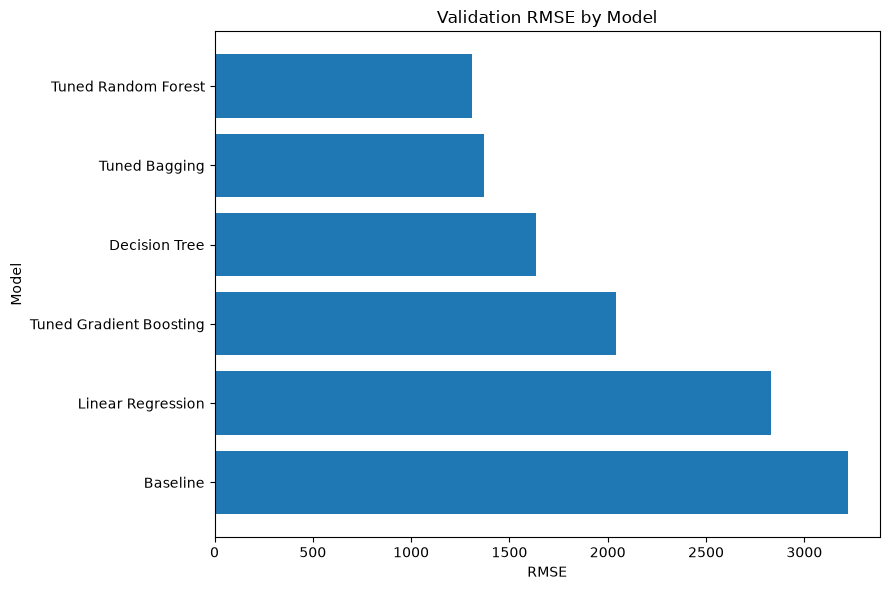

In [34]:
# Compare validation RMSE across models

model_chart = final_model_results.sort_values(
    "RMSE",
    ascending=False
)

plt.figure(figsize=(9, 6))

plt.barh(
    model_chart["Model"],
    model_chart["RMSE"]
)

plt.xlabel("RMSE")
plt.ylabel("Model")
plt.title("Validation RMSE by Model")

plt.tight_layout()
plt.show()

### Original vs. Tuned Model Performance

To evaluate whether hyperparameter tuning improved model performance, the validation metrics from the original ensemble models were compared with their tuned versions. Lower MAE and RMSE values indicate better prediction accuracy, while a higher R² indicates that the model explains more of the variation in sales.

In [42]:
# Compare original and tuned ensemble model performance
tuning_comparison = pd.DataFrame({
    "Model": [
        "Bagging",
        "Bagging - Tuned",
        "Random Forest",
        "Random Forest - Tuned",
        "Gradient Boosting",
        "Gradient Boosting - Tuned"
    ],
    "MAE": [
        bagging_mae,
        best_bagging_mae,
        rf_mae,
        best_rf_150_mae,
        gb_mae,
        best_gb_mae
    ],
    "RMSE": [
        bagging_rmse,
        best_bagging_rmse,
        rf_rmse,
        best_rf_150_rmse,
        gb_rmse,
        best_gb_rmse
    ],
    "R2": [
        bagging_r2,
        best_bagging_r2,
        rf_r2,
        best_rf_150_r2,
        gb_r2,
        best_gb_r2
    ]
})

tuning_comparison

,Model,MAE,RMSE,R2
0,Bagging,881.478309,1370.822232,0.815935
1,Bagging - Tuned,879.609123,1369.267816,0.816352
2,Random Forest,879.953531,1371.183571,0.815838
3,Random Forest - Tuned,845.594879,1311.458563,0.831531
4,Gradient Boosting,1865.536741,2544.902923,0.365616
5,Gradient Boosting - Tuned,1503.022739,2040.161525,0.592302


### Final Test Set Evaluation

The tuned Random Forest was selected as the final model based on validation performance. The model is now evaluated once on the previously untouched test set to estimate its final generalization performance.

In [35]:
# Evaluate the selected final model on the untouched test set

final_test_pred = best_rf_150.predict(X_test)

final_test_mae = mean_absolute_error(
    y_test,
    final_test_pred
)

final_test_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        final_test_pred
    )
)

final_test_r2 = r2_score(
    y_test,
    final_test_pred
)

print("Final Tuned Random Forest - Test Set")
print("MAE:", round(final_test_mae, 2))
print("RMSE:", round(final_test_rmse, 2))
print("R²:", round(final_test_r2, 4))

Final Tuned Random Forest - Test Set
MAE: 780.02
RMSE: 1146.36
R²: 0.8654


### Final Model Performance

The tuned Random Forest remained the strongest model when evaluated on the previously untouched test set. It achieved an MAE of 780.02, RMSE of 1146.36, and R² of 0.8654.

The test results were slightly stronger than the validation results, indicating that the selected model generalized well to unseen data. Based on both validation and test performance, the tuned Random Forest was retained as the final predictive model.

### Actual vs. Predicted Sales

Actual test-set sales are compared with the final Random Forest predictions. Points closer to the diagonal reference line indicate more accurate predictions.

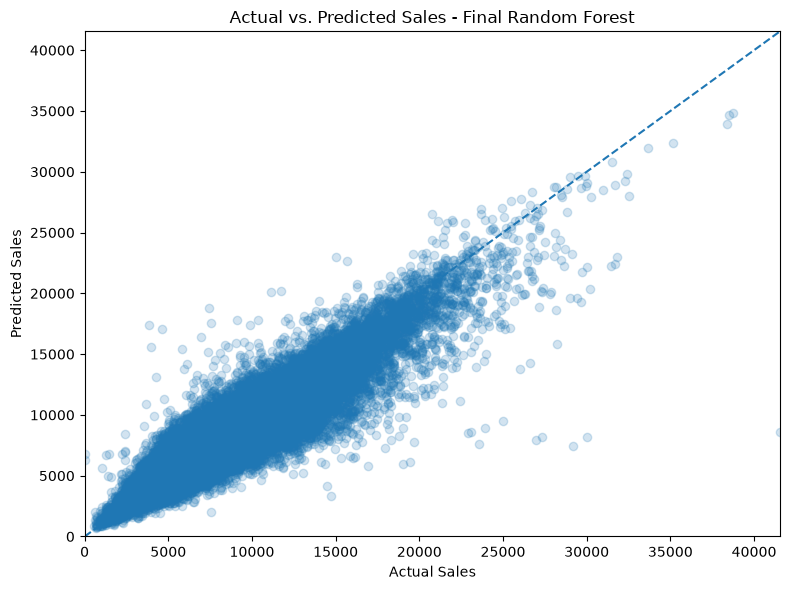

In [36]:
# Actual vs. predicted sales for the final model

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    final_test_pred,
    alpha=0.2
)

# Reference line for perfect predictions
min_value = min(y_test.min(), final_test_pred.min())
max_value = max(y_test.max(), final_test_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs. Predicted Sales - Final Random Forest")
plt.xlim(0, max_value)
plt.ylim(0, max_value)
plt.tight_layout()
plt.show()

### Actual vs. Predicted Interpretation

Most observations fall relatively close to the diagonal reference line, indicating that the final Random Forest generally tracks actual sales well across the test set. The spread becomes wider at higher sales values, showing that prediction error increases for some high-sales observations.

A small number of extreme sales values are substantially underpredicted, but the overall pattern is consistent with the model's strong test performance of RMSE 1146.36 and R² of 0.8654.

### Final Model Selection

The tuned Random Forest was selected as the final model because it produced the strongest validation performance among all models tested. It achieved the lowest validation MAE and RMSE and the highest R², outperforming tuned Bagging, Gradient Boosting, the Decision Tree, Linear Regression, and the baseline model.

Its performance remained strong on the untouched test set, with an MAE of 780.02, RMSE of 1146.36, and R² of 0.8654. These results support using the tuned Random Forest as the final predictive model for Rossmann daily sales.

### Feature Importance

Feature importance from the final tuned Random Forest is examined to identify which predictors contributed most to the model's sales predictions.

In [37]:
# Extract feature names after preprocessing
feature_names = best_rf_150.named_steps["preprocessor"].get_feature_names_out()

# Extract feature importance values from the Random Forest
feature_importance = best_rf_150.named_steps["model"].feature_importances_

# Create feature importance table
feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": feature_importance
})

# Show the 15 most important features
feature_importance_df = feature_importance_df.sort_values(
    "Importance",
    ascending=False
)

feature_importance_df.head(15)

,Feature,Importance
19,remainder__Store,0.304913
26,remainder__CompetitionDistance,0.275456
21,remainder__Promo,0.138075
20,remainder__DayOfWeek,0.057519
23,remainder__Day,0.046876
22,remainder__Month,0.038283
9,cat__StoreType_b,0.023124
8,cat__StoreType_a,0.016897
11,cat__StoreType_d,0.014800
14,cat__Assortment_c,0.012903


### Feature Importance Interpretation

The final Random Forest model identified store identity, competition distance, and promotion status as the most influential predictors of daily sales. Store identity had the largest importance, indicating that sales patterns vary substantially across individual locations. Competition distance was the second most important feature, suggesting that nearby competitive conditions are strongly associated with sales performance.

Promotion status was also one of the strongest predictors, supporting the project's focus on promotion effectiveness. Calendar variables such as day of the week, day of the month, and month also contributed to predictions, indicating that sales vary over time and across seasonal periods.

Store type and assortment characteristics contributed additional predictive value, although their individual importance was smaller than the leading store, competition, and promotion variables.

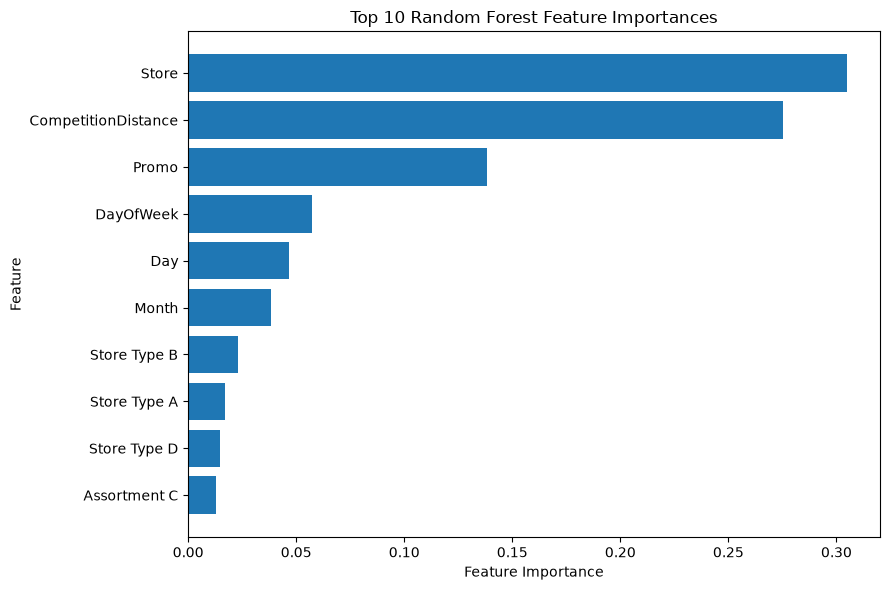

In [38]:
# Create cleaner feature labels for the top 10 features
top_features = feature_importance_df.head(10).copy()

top_features["Feature"] = (
    top_features["Feature"]
    .str.replace("remainder__", "", regex=False)
    .str.replace("cat__", "", regex=False)
    .str.replace("StoreType_b", "Store Type B", regex=False)
    .str.replace("StoreType_a", "Store Type A", regex=False)
    .str.replace("StoreType_d", "Store Type D", regex=False)
    .str.replace("Assortment_c", "Assortment C", regex=False)
)

top_features = top_features.sort_values(
    "Importance",
    ascending=True
)

plt.figure(figsize=(9, 6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 10 Random Forest Feature Importances")

plt.tight_layout()
plt.show()

The feature importance results show that store identity, competition distance, and promotion status were the strongest contributors to the final Random Forest predictions. Store-level differences were the most important, followed closely by competition distance, while promotion status was the strongest business-actionable predictor. Calendar variables such as day of week, day, and month also contributed to sales prediction.

These importance values describe predictive contribution within the Random Forest model and should not be interpreted as causal effects. Random Forest feature importance can favor continuous or high-cardinality variables, so these rankings should be interpreted as model-based indicators rather than exact measures of business impact.

### Discussion and Business Implications

The modeling results show that nonlinear tree-based methods were much more effective than the simpler baseline and Linear Regression models for predicting Rossmann daily sales. The tuned Random Forest produced the strongest overall performance, achieving an R² of 0.8315 on the validation set and 0.8654 on the test set.

The feature importance results indicate that store-level differences, competition distance, promotion status, and calendar variables are important for predicting sales. Promotion was one of the strongest actionable predictors, which supports the project's focus on understanding where promotional activity may have the greatest value.

From a business perspective, Rossmann should avoid treating all stores as if they respond the same way. Promotion planning should consider individual store characteristics, competitive conditions, and timing. Stores operating under different competitive environments or with different historical sales patterns may benefit from different promotional strategies.

These results should be interpreted as predictive relationships rather than causal effects. The model can help identify patterns and support promotion planning, but it does not prove that changing a single factor will directly cause a specific change in sales.

### Limitations and Future Work

Several limitations should be considered when interpreting the modeling results. First, the models identify predictive relationships but do not establish causal effects. For example, promotion status was an important predictor, but the model does not prove that promotions alone caused the observed sales changes.

Second, hyperparameter tuning was performed on a representative subset of the training data to reduce computational demands. Although the selected models were retrained on the full training set, a larger or more extensive tuning search could potentially identify additional improvements.

Third, the model uses the variables available in the Rossmann dataset and does not include other factors that may influence sales, such as local economic conditions, weather, competitor promotions, or detailed customer behavior.

Store is represented by its numeric identifier in the current model. Although tree-based models can use this variable to distinguish store-level patterns, the numeric ordering of store IDs has no inherent business meaning; future work could evaluate alternative categorical or store-specific encoding approaches.

Future work could test additional model configurations, incorporate external data sources, and examine promotion effectiveness at a more detailed store or regional level. Further analysis could also focus on identifying which specific store segments are most likely to benefit from promotional activity.

## Model Brief

The modeling strategy compared a simple baseline, Linear Regression, a Decision Tree, Bagging, Random Forest, and Gradient Boosting to predict Rossmann daily sales. Linear Regression was included as an interpretable benchmark, while the tree-based models were used to capture nonlinear relationships and interactions among promotions, store characteristics, competition, holidays, and calendar variables.

The initial comparison showed that Bagging and Random Forest substantially outperformed the baseline, Linear Regression, Decision Tree, and Gradient Boosting models. Bagging and Random Forest therefore received the greatest tuning attention, while Gradient Boosting was also tuned to determine whether its weaker default performance could be improved.

Hyperparameter tuning was performed on a reproducible subset of the training data to reduce computational demands. The strongest Random Forest configuration used 150 trees, unrestricted tree depth, 80% of available transformed features at each split, and a minimum leaf size of 1. After retraining on the full training set, this model achieved the strongest validation performance with an MAE of 845.59, RMSE of 1311.46, and R² of 0.8315.

The tuned Random Forest was selected as the final model and was evaluated once on the previously untouched test set. It achieved an MAE of 780.02, RMSE of 1146.36, and R² of 0.8654, indicating strong generalization to unseen observations.

The modeling results also showed that store identity, competition distance, promotion status, and calendar variables were the most influential predictors. Promotion was one of the strongest actionable predictors, but the model should be interpreted as predictive rather than causal.

Known limitations include the use of a reduced tuning subset, the computational limits that restricted broader hyperparameter searches, and the absence of external factors such as weather, local economic conditions, competitor promotions, and detailed customer behavior.

Recommended next steps include testing additional model configurations, incorporating external data sources, evaluating model stability across store segments and time periods, and conducting more targeted analysis of promotion effectiveness by store type, season, holiday period, and competitive environment.

### GitHub Link: https://github.com/raminfazlirf/ADS-505_group-project.git